# BIOINF 580 - HW 01

### Due Monday, Sep 28 at 11:59pm

---

## Asystole Detection in ECG

**GOAL:** Detect when asystole occurs in an ECG signal.  

**Definition:** Asystole is defined as the **absence of the QRS complex for at least 4 seconds**.

---

## General Instructions

- Please **answer all questions** in this report with clear, written responses and complete sentences.

- Provide **comments for all code blocks**, so that readers can easily understand the purpose and logic of each step. 

- Each plot must have a **descriptive title, axis labels with units, and a legend** (when appropriate) to ensure clarity.  

- Provide any **references** (textbooks, articles, online sources, etc.) that you used to prepare your report and code.

- Mute any **unnecessary code output** using `#` to comment out print/debug lines or other non-essential outputs, so the notebook remains clean and readable.

---

## Submission Requirement:  

- Submit the Jupyter notebook (`.ipynb`) file with all code and the written report included.  

- Name the file as: `HW01_YourUniqueName.ipynb`

---

## Part I - ECG Signal Preprocessing

### 1.	(5 pts) Initial Visualization:

##### 1.1 (1 pt) Download and Open ECG Data

Download `ecg_data_hw1.csv` from `Assignments > Homework assignments > HW 01` on Canvas and open it. 
(Note: The file contains an ECG signal in the first column that ends in asystole.)

$\textcolor{red}{\text{The sampling rate for the raw ECG signal is 250 Hz.}}$

In [1]:
import pandas as pd

# Load the ECG data from CSV file
# Assumes the file "ecg_data_hw1.csv" is in the same working directory as this notebook
ecg_data = pd.read_csv("ecg_data_hw1.csv", header=None)

# Preview the shape of the dataset (rows, columns)
print(ecg_data.shape)

(82500, 1)


##### 1.2 (2 pts) Plot the Raw ECG Signal

Plot the raw ECG signal, with time in seconds (s) on the x-axis.


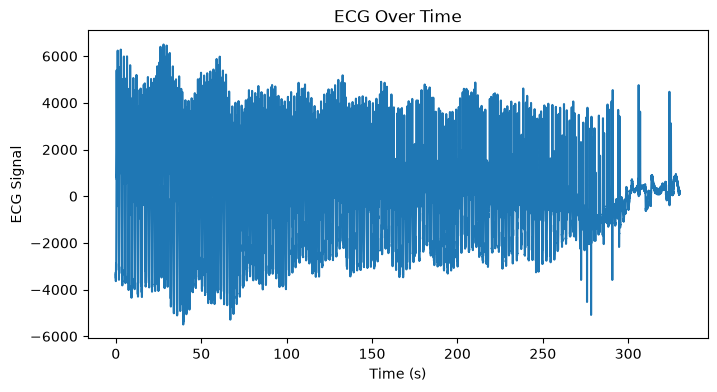

In [2]:
# (Your code for Section 1.2 goes here)
import matplotlib.pyplot as plt
import numpy as np

# get time based on frequency and signal
Fs = 250
t = np.arange(0, len(ecg_data)/Fs, 1/Fs)
x = ecg_data[0]

# plot
plt.figure(figsize=(8,4))
plt.plot(t, x)
plt.title("ECG Over Time")
plt.xlabel("Time (s)")
plt.ylabel("ECG Signal")
plt.show()


##### 1.3 (2 pts) Visual Inspection of the ECG Signal

Visually inspect the ECG signal. Which components or features can you identify?

<-- Write your report for Section 1.3 here -->

There is a wide spectrum of frequencies, from high to low. The signal is characterized by recurring high amplitude signal. However, there seems to be a drastic change in the signal at around 300 seconds, where the asystole seems to be happening. Here, the amplitude of the signal seems to get "muted" for a few seconds as opposed to the recurring high amplitude signal leading up to it.

### 2. (10 pts) Fourier Transform:

### 2.1 (5 pts) Fourier Transform and Plotting

Find the Fourier Transform (FT) of the ECG signal by applying the Fast Fourier Transform (FFT).
(Note: Before performing the transform, make sure the signal is stored as a **1D NumPy array**.)

Plot **only the positive half of the frequency spectrum**, with:  
- Magnitude spectrum on the y-axis  
- Positive frequencies (in Hz) on the x-axis

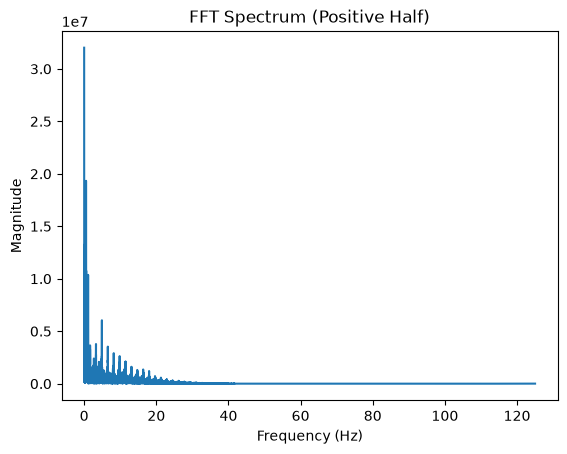

In [3]:
# (Your code for Section 2.1 goes here)

# do FFT to get |H(f)|
ft = np.fft.fft(x.to_numpy())
magnitude = np.abs(ft)
# get frequencies
freqs = np.fft.fftfreq(len(ft), d=1/Fs)

# Plot only positive half
plt.figure()
plt.plot(freqs[:len(freqs)//2], magnitude[:len(freqs)//2])   # //: floor division (always rounds down, e.g. 7//2 = 3)
plt.title("FFT Spectrum (Positive Half)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.show()


##### 2.2 (5 pts) Dominant Frequencies

What are the dominant frequencies in the Fourier Transform (FT) based on your observations?  
What do these frequencies most likely correspond to? (Note: Please provide references to support your interpretation.)

<-- Write your report for Section 2.2 here -->

The largest peak sits near 0–0.3 Hz, strong peaks follow at roughly 1–1.5 Hz, and a series of evenly spaced, steadily decaying harmonic peaks (with a notable one near 5 Hz) extends to about 30–40 Hz. Above roughly 40 Hz there is almost no energy. This pattern is characteristic of an electrocardiogram (ECG). The ~1–1.5 Hz fundamental corresponds to the heart rate (about 60–90 bpm), and the regularly spaced peaks are its harmonics, which arise because the heartbeat is a periodic but non-sinusoidal waveform. The concentration of energy around 5–15 Hz reflects the QRS complex (Thakor, Webster & Tompkins, 1984, IEEE Trans. Biomed. Eng.; Pan & Tompkins, 1985, IEEE Trans. Biomed. Eng.). The large sub-0.5 Hz component most likely reflects DC offset, baseline wander, or respiration, which typically falls around 0.15–0.4 Hz (Task Force of the ESC/NASPE, 1996, Circulation). The negligible content above ~40 Hz matches the known diagnostic ECG bandwidth (Kligfield et al., 2007, Circulation).


### 3. (10 pts) Filtering:

##### 3.1 (5 pts) Bandpass Filtering to Remove Noise 

The signal contains noise at both high and low frequencies. Apply a bandpass filter to remove this noise, using a cutoff frequency range of 5 Hz to 50 Hz.

In [4]:
# (Your code for Section 3.1 goes here)
from scipy import signal

# apply filter
b_bp, a_bp = signal.butter(4, [5, 50], fs=Fs, btype="band")
y_bp = signal.filtfilt(b_bp, a_bp, x)

##### 3.2 (5 pts) Justification for Bandpass Filtering 

Why should we use a bandpass filter on this signal instead of a lowpass or highpass filter?  
What might be some sources of the noise we are trying to remove? (Note: Please provide references to support your interpretation.)

<-- Write your report for Section 3.2 here -->

A bandpass filter works best because this ECG has noise at both ends of the spectrum, while the useful cardiac signal sits in a middle band of roughly 0.5–40 Hz. A lowpass filter alone would leave the large low-frequency drift near 0 Hz. A highpass filter alone would leave the high-frequency noise. A bandpass filter removes both at once. The low-frequency noise is mainly baseline wander from breathing, body movement, and shifting electrode contact. The high-frequency noise comes mainly from muscle activity (EMG) and 50/60 Hz powerline interference (Clifford, Azuaje & McSharry, 2006, Advanced Methods and Tools for ECG Data Analysis).

### 4. (25 pts) Comparison:

##### 4.1 (10 pts) Comparison between Raw and Filtered Signals in the Time Domain

Identify a 5-second window where the filtered ECG differs significantly from the raw ECG in the same interval.  
Using a 2-row subplot, plot this 5-second window with the raw signal on the top and the filtered signal on the bottom. (Note: Be sure to label the plots clearly.)

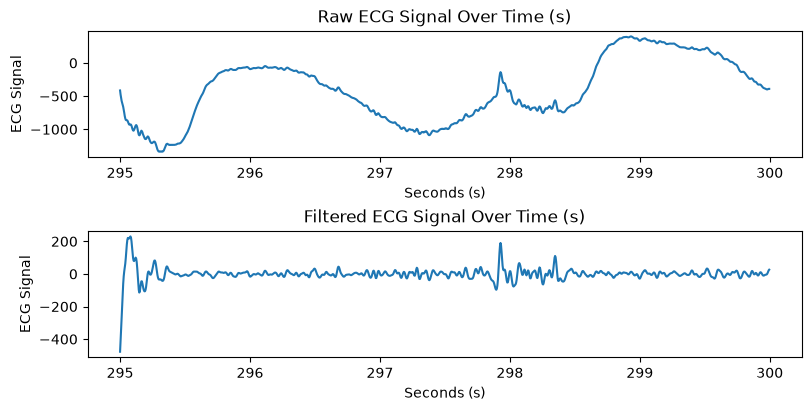

In [5]:
# (Your code for Section 4.1 goes here)

# # plot raw & filtered signal
# plt.figure()
# plt.plot(t[200*Fs:], x[200*Fs:], label='Raw')
# plt.plot(t[200*Fs:], y_bp[200*Fs:], label="Filtered")
# plt.show()

# set start of 5-second window
t_0 = 295

# plot
fig, axes = plt.subplots(2, 1, figsize=(8, 4), constrained_layout=True)
# plot raw signal on row 1
axes[0].plot(t[t_0 * Fs:(t_0 + 5) * Fs], x[t_0 * Fs:(t_0 + 5) * Fs])
axes[0].set_title("Raw ECG Signal Over Time (s)")
axes[0].set_xlabel("Seconds (s)")
axes[0].set_ylabel("ECG Signal")
# plot filtered signal on row 2
axes[1].plot(t[t_0 * Fs:(t_0 + 5) * Fs], y_bp[t_0 * Fs:(t_0 + 5) * Fs])
axes[1].set_title("Filtered ECG Signal Over Time (s)")
axes[1].set_xlabel("Seconds (s)")
axes[1].set_ylabel("ECG Signal")
plt.show()

##### 4.2 (15 pts) Comparison between Raw and Filtered Signals in the Frequency Domain

Plot the positive half of the frequency spectrum (as in Section 2.1) for the entire filtered signal and overlay it on the Fourier Transform (FT) of the raw signal.  
Describe the differences between the two signals. Which frequencies were removed by the bandpass filter, and what might they represent?

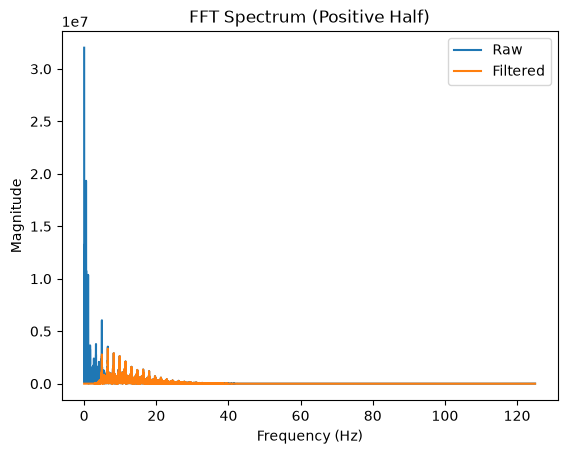

In [6]:
# (Your code for Section 4.2 goes here)

# do FFT to get |H(f)|
ft_bp = np.fft.fft(y_bp)
magnitude_bp = np.abs(ft_bp)
# get frequencies
freqs_bp = np.fft.fftfreq(len(ft_bp), d=1/Fs)


# Plot only positive half
plt.figure()
plt.plot(freqs[:len(freqs)//2], magnitude[:len(freqs)//2], label='Raw')
plt.plot(freqs_bp[:len(freqs_bp)//2], magnitude_bp[:len(freqs_bp)//2], label="Filtered")   # //: floor division (always rounds down, e.g. 7//2 = 3)
plt.title("FFT Spectrum (Positive Half)")
plt.xlabel("Frequency (Hz)")
plt.ylabel("Magnitude")
plt.legend()
plt.show()

<-- Write your report for Section 4.2 here -->

The raw signal is dominated by large peaks below 5 Hz, while the filtered signal keeps only the content between 5 and 50 Hz, so those low-frequency peaks are gone and the rest of the spectrum looks nearly unchanged. The 5 Hz cutoff removed the DC offset, baseline wander from breathing and movement, and the heart-rate fundamental with its first few harmonics, which also weakens the slower P and T waves. What remains is mostly the QRS complex, which is useful for detecting heartbeats (Pan & Tompkins, 1985). The 50 Hz cutoff removed any higher-frequency noise, such as muscle activity and some powerline interference, but so little energy existed above 50 Hz that the change isn't visible on this plot.

## Part II - Asystole Detection in ECG

### 5. (50 pts) Asystole Detection Function

##### 5.1 (15 pts) Function Design

Write a Python function that raises an alarm when asystole is detected. Your function should:

- Take as input the **ECG signal (`ecg`)** and the **sampling rate (`Fs`)**.  
- Use a **sliding window** on the **filtered ECG signal** (you may reuse your Section 3 filter or design a different one, as long as you justify your choice):  
  - Window length = **4 seconds** (minimum needed to detect asystole).  
  - Sliding interval = **1 second**.  
  - For example, check seconds 0–4, then 1–5, 2–6, and so on.  
  - The output binary array (`alarm`) should have a length of approximately **327**.  
- Select a **feature or value** for each window that can distinguish between normal ECG activity and asystole.  
- Apply a **threshold or decision rule** to determine whether the alarm should be raised in each window.  
- Return both:  
  - A binary array (`alarm`) indicating whether the alarm is raised at each step.  
  - The **start time (in seconds) of the first window** in which asystole is detected, or 0 if none is detected.  
- Comment your code clearly and mute any unnecessary output using `#`.

In [7]:
import numpy as np
from scipy.signal import butter, filtfilt, find_peaks


def asystole_detection(ecg, Fs):
    """
    Detect asystole in an ECG signal using a sliding window approach.

    Parameters:
        ecg (array): Unfiltered ECG signal
        Fs (int or float): Sampling frequency in Hz

    Returns:
        alarm (array): Binary array (0 = normal, 1 = asystole) for each window
        first_asystole_time (float): Start time (s) of the first window with detected asystole, or 0 if none
    """
    ecg = np.asarray(ecg, dtype=float)

    # ---------------------------------------------------------------
    # 1) Filter the signal (reusing the Section 3 bandpass, 5-50 Hz)
    #    - 5 Hz low cutoff removes baseline wander and the slow P/T waves
    #    - 50 Hz high cutoff removes muscle noise and powerline interference
    #    - What remains is mostly the QRS complex, which is exactly what
    #      we need: asystole = no QRS complexes (no heartbeats)
    #    - filtfilt gives zero phase shift, so peaks stay aligned in time
    # ---------------------------------------------------------------
    low, high = 5, 50
    b, a = butter(4, [low, high], btype='band', fs=Fs)
    ecg_filt = filtfilt(b, a, ecg)

    # ---------------------------------------------------------------
    # 2) Detect QRS peaks once on the whole filtered signal
    #    - Use the absolute value so QRS polarity does not matter
    #    - Height threshold: 35% of the 99th percentile amplitude
    #      (percentile instead of max so one noise spike can't set it)
    #    - Minimum distance of 0.3 s between peaks (max ~200 bpm)
    # ---------------------------------------------------------------
    env = np.abs(ecg_filt)
    height_thr = 0.35 * np.percentile(env, 99)
    peaks, _ = find_peaks(env, height=height_thr, distance=int(0.3 * Fs))
    # print("Total peaks detected:", len(peaks))

    # ---------------------------------------------------------------
    # 3) Sliding window: 4 s long, moved by 1 s each step
    # ---------------------------------------------------------------
    win_len = int(4 * Fs)                      # samples per window
    step = int(1 * Fs)                         # samples per step
    n_windows = (len(ecg_filt) - win_len) // step + 1
    # print(n_windows)

    alarm = np.zeros(n_windows, dtype=int)

    for i in range(n_windows):
        start = i * step
        stop = start + win_len

        # Feature: number of QRS peaks inside this window
        n_beats = np.sum((peaks >= start) & (peaks < stop))

        # Decision rule: no heartbeat in 4 s -> asystole -> raise alarm
        if n_beats == 0:
            alarm[i] = 1
        # print(f"Window {i}-{i+4} s: {n_beats} beats, alarm = {alarm[i]}")

    # ---------------------------------------------------------------
    # 4) Start time (s) of the first window that raised the alarm
    # ---------------------------------------------------------------
    alarm_idx = np.where(alarm == 1)[0]
    first_asystole_time = alarm_idx[0] * step / Fs if len(alarm_idx) > 0 else 0

    # print("Number of windows:", len(alarm))
    # print("First asystole at:", first_asystole_time, "s")

    return alarm, first_asystole_time

##### 5.2 (15 pts) Implement the Function and Plot Results

Implement your `asystole_detection` function from Section 5.1 and test it on the provided ECG data.  

- Apply your function to the ECG signal and record both the **alarm array** and the **first asystole detection time (in seconds)**.  
- Plot the results using a 2-row subplot:  
  - **Top subplot:** the raw ECG signal versus time (in seconds).  
  - **Bottom subplot:** the alarm array as a step plot, with time on the x-axis (window start times, 1-second hops) and the binary alarm (0 = normal, 1 = asystole) on the y-axis.  
- Add appropriate **titles, axis labels, legends, and grids** for clarity.  
- After plotting, print a message that reports the time of the first detected asystole (or indicate if none was detected).


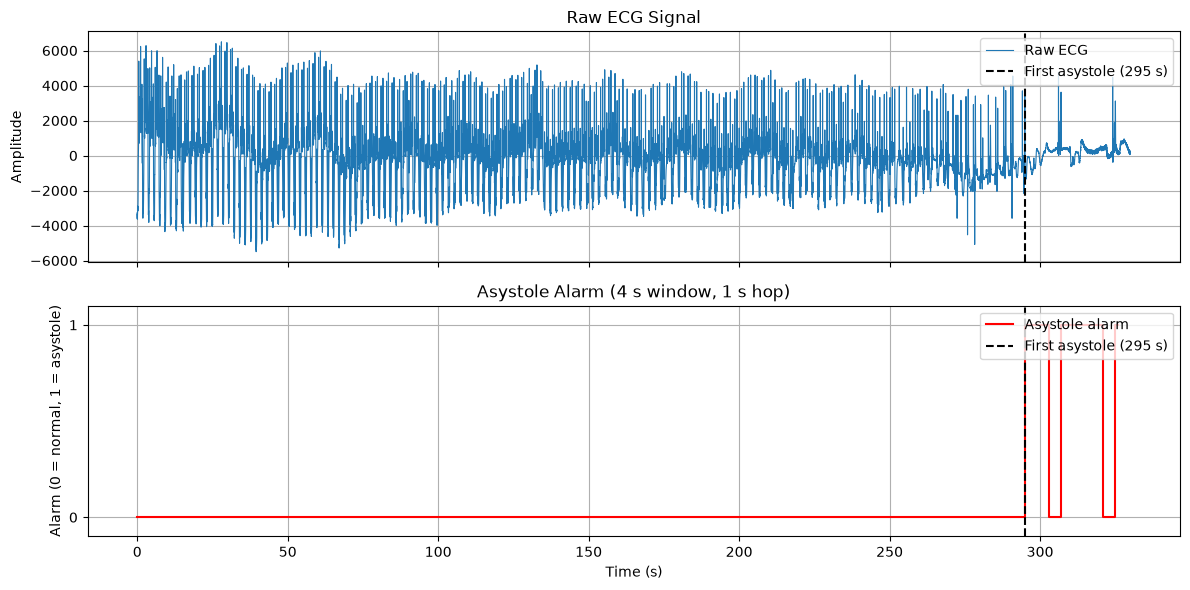

First asystole detected in the window starting at 295 s.


In [8]:
# (Your code for Section 5.2 goes here)

import numpy as np
import matplotlib.pyplot as plt

ecg = x

# Run the asystole detection function
alarm, first_asystole_time = asystole_detection(ecg, Fs)

# Time axes
t_ecg = np.arange(len(ecg)) / Fs          # ECG time in seconds
t_alarm = np.arange(len(alarm)) * 1.0     # window start times (1 s hops)
 
# print("Alarm array length:", len(alarm))
 
# ---------------------------------------------------------------
# Plot: raw ECG (top) and alarm (bottom)
# ---------------------------------------------------------------
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
 
# Top: raw ECG
ax1.plot(t_ecg, ecg, label='Raw ECG', linewidth=0.8)
ax1.set_title('Raw ECG Signal')
ax1.set_ylabel('Amplitude')
ax1.legend(loc='upper right')
ax1.grid(True)
 
# Bottom: alarm as a step plot
ax2.step(t_alarm, alarm, where='post', color='red', label='Asystole alarm')
ax2.set_title('Asystole Alarm (4 s window, 1 s hop)')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Alarm (0 = normal, 1 = asystole)')
ax2.set_yticks([0, 1])
ax2.set_ylim(-0.1, 1.1)
ax2.grid(True)
 
# Mark the first detection on both plots (only if an alarm was raised)
if alarm.any():
    for ax in (ax1, ax2):
        ax.axvline(first_asystole_time, color='black', linestyle='--',
                   label=f'First asystole ({first_asystole_time:.0f} s)')
    ax1.legend(loc='upper right')
 
ax2.legend(loc='upper right')
plt.tight_layout()
plt.show()
 
# ---------------------------------------------------------------
# Report result
# (checks alarm.any() because a return value of 0 could mean either
#  "none detected" or "detected in the very first window")
# ---------------------------------------------------------------
if alarm.any():
    print(f"First asystole detected in the window starting at {first_asystole_time:.0f} s.")
else:
    print("No asystole detected.")


##### 5.3 (10 pts) Why did you choose the feature or value you selected?
    
(Note: Please provide references to support your interpretation.)

<-- Write your report for Section 5.3 here -->

I chose the number of QRS peaks per window as the feature because it directly reflects the definition of asystole: no heartbeats, meaning no QRS complexes. After the 5–50 Hz bandpass filter, the QRS complexes are the largest, sharpest features left in the signal, so they can be detected reliably with a simple amplitude threshold. A beat count is also more robust than amplitude or energy, which vary with recording conditions and electrode placement, because it only asks whether any beat is present. This builds on established QRS detection methods, which bandpass filter the ECG to isolate QRS energy before detecting peaks (Pan & Tompkins, 1985, IEEE Trans. Biomed. Eng.).


##### 5.4 (10 pts) Why did you choose the specific threshold or metric for detecting asystole?

(Note: Please provide references to support your interpretation.)

<-- Write your report for Section 5.4 here -->

The decision rule raises the alarm when a 4-second window contains zero beats. This follows the standard clinical alarm definition of asystole as no QRS complex for at least 4 seconds. A peak counts as a beat only if it reaches 35% of the signal's 99th-percentile amplitude, a level between the R-peaks and the leftover noise that adapts to each recording and isn't skewed by single spikes. Peaks must also be at least 0.3 s apart, which allows heart rates up to 200 bpm while preventing one QRS complex from being counted twice. Both values are empirical choices, following the general approach of using a fractional amplitude threshold and a minimum spacing between beats, as in the detector of Pan & Tompkins (1985), which used a 200 ms refractory period.


# Generative AI Disclosure

I used Claude and Gemini Notebook to support my work on this homework assignment, including clarifying relevant concepts, interpreting questions, brainstorming approaches, and troubleshooting or improving code across multiple problems. I independently reviewed and verified all AI-generated suggestions, corrected any errors, and completed the final solutions myself. I take full responsibility for the accuracy, reasoning, code, and conclusions in the submitted work.